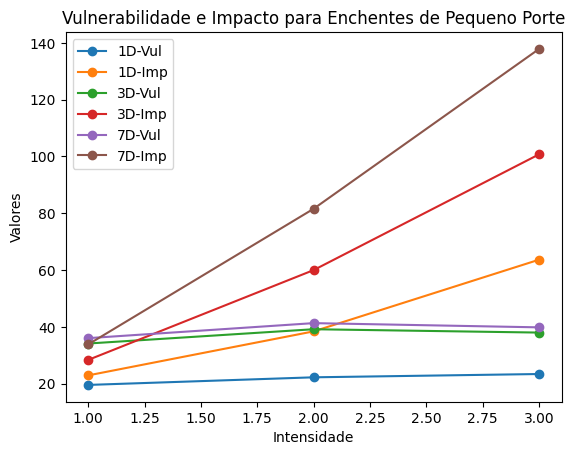

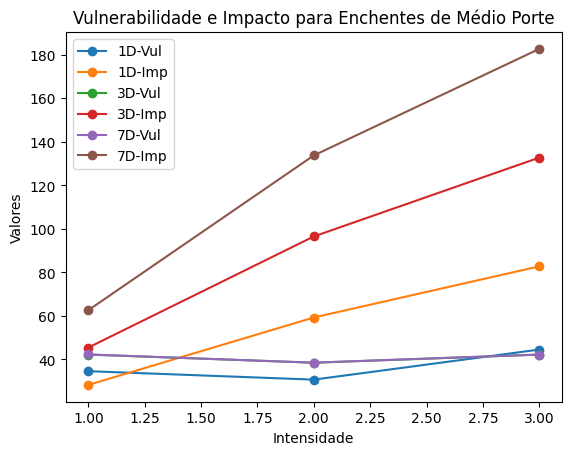

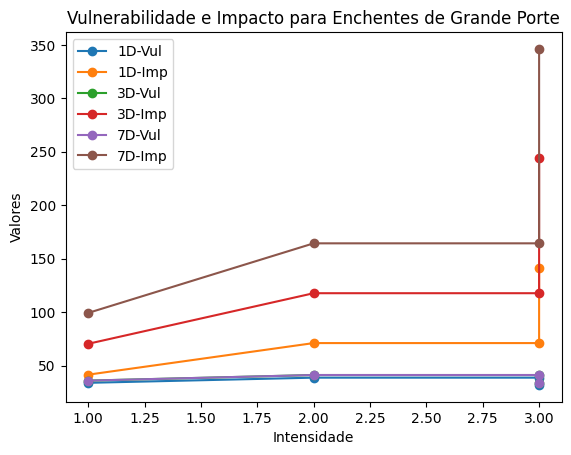

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

# Create the DataFrame based on the provided image data
data = {
    "Ano": [1980] * 10,
    "1D-Vul": [19.55, 22.23, 23.39, 34.61, 30.73, 44.54, 33.93, 38.76, 38.76, 31.97],
    "1D-Imp": [22.91, 38.41, 63.65, 28.30, 59.27, 82.77, 41.56, 71.10, 71.10, 141.40],
    "3D-Vul": [34.13, 39.16, 37.98, 42.25, 38.50, 42.22, 35.99, 41.23, 41.23, 33.58],
    "3D-Imp": [28.36, 59.99, 100.75, 45.46, 96.49, 132.71, 70.43, 117.73, 117.73, 243.78],
    "7D-Vul": [36.02, 41.31, 39.82, 42.28, 38.52, 42.25, 35.99, 41.23, 41.23, 33.58],
    "7D-Imp": [33.82, 81.58, 137.86, 62.63, 133.71, 182.64, 99.30, 164.37, 164.37, 346.16],
    "Porte": ["Pequeno", "Pequeno", "Pequeno", "Médio", "Médio", "Médio", "Grande", "Grande", "Grande", "Grande"],
    "Intensidade": [1, 2, 3, 1, 2, 3, 1, 2, 3, 3]
}

df = pd.DataFrame(data)

# Filter data by 'Porte' and plot graphs for each category
portes = ["Pequeno", "Médio", "Grande"]
for porte in portes:
    filtered_df = df[df["Porte"] == porte]
    plt.figure()
    plt.plot(filtered_df["Intensidade"], filtered_df["1D-Vul"], label="1D-Vul", marker='o')
    plt.plot(filtered_df["Intensidade"], filtered_df["1D-Imp"], label="1D-Imp", marker='o')
    plt.plot(filtered_df["Intensidade"], filtered_df["3D-Vul"], label="3D-Vul", marker='o')
    plt.plot(filtered_df["Intensidade"], filtered_df["3D-Imp"], label="3D-Imp", marker='o')
    plt.plot(filtered_df["Intensidade"], filtered_df["7D-Vul"], label="7D-Vul", marker='o')
    plt.plot(filtered_df["Intensidade"], filtered_df["7D-Imp"], label="7D-Imp", marker='o')
    plt.xlabel("Intensidade")
    plt.ylabel("Valores")
    plt.title(f"Vulnerabilidade e Impacto para Enchentes de {porte} Porte")
    plt.legend()
    plt.show()


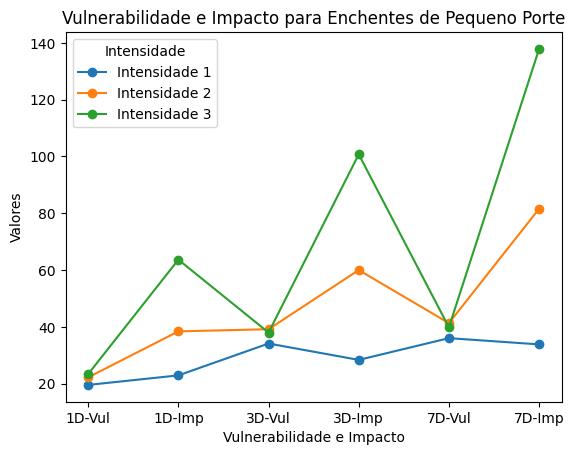

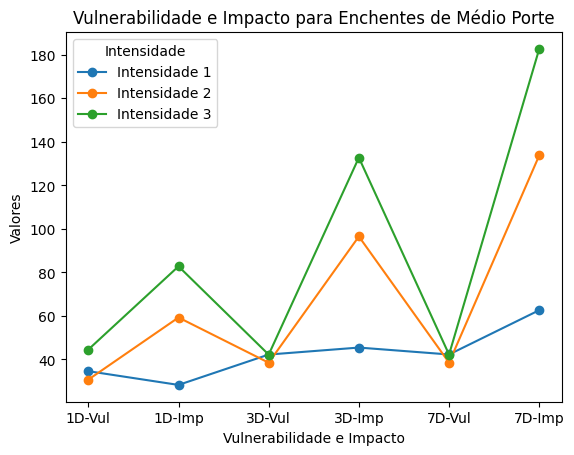

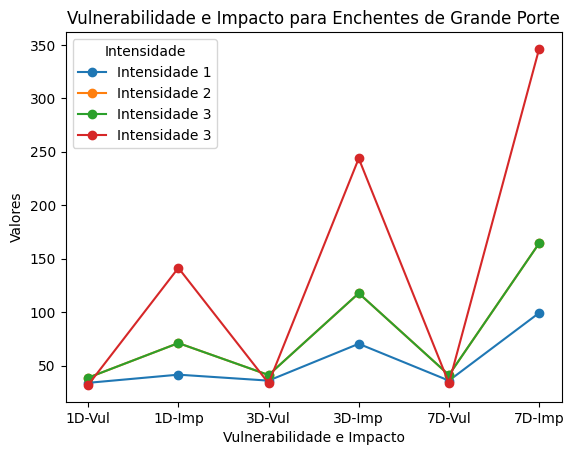

In [2]:
# Re-plotting the graphs with Vulnerability and Impact on the x-axis
for porte in portes:
    filtered_df = df[df["Porte"] == porte]
    plt.figure()
    plt.plot(["1D-Vul", "1D-Imp", "3D-Vul", "3D-Imp", "7D-Vul", "7D-Imp"],
             filtered_df[["1D-Vul", "1D-Imp", "3D-Vul", "3D-Imp", "7D-Vul", "7D-Imp"]].values.T, marker='o')
    plt.xlabel("Vulnerabilidade e Impacto")
    plt.ylabel("Valores")
    plt.title(f"Vulnerabilidade e Impacto para Enchentes de {porte} Porte")
    plt.legend([f"Intensidade {i}" for i in filtered_df["Intensidade"].values], title="Intensidade")
    plt.show()


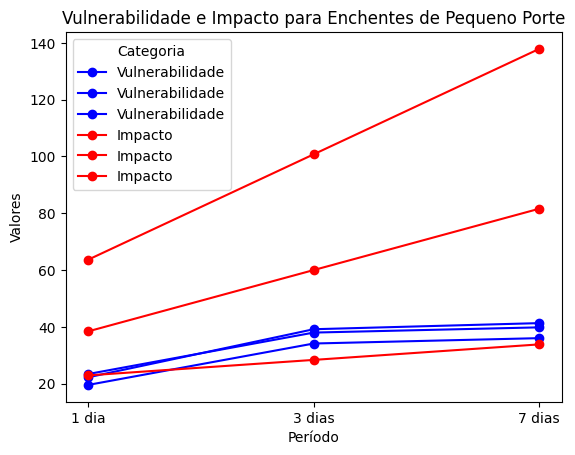

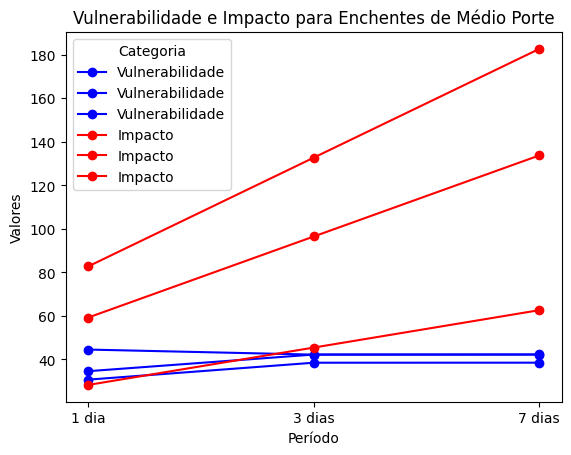

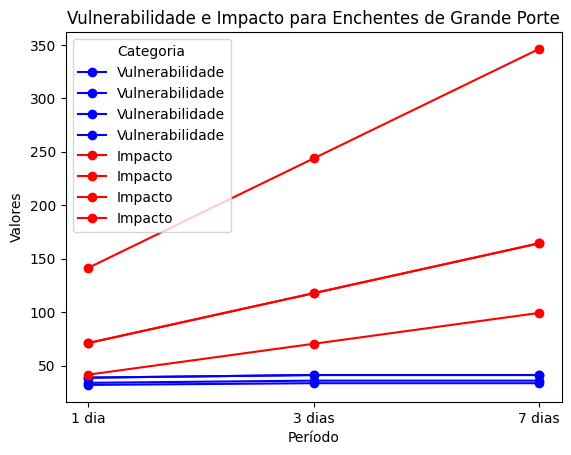

In [3]:
# Re-plotting with the specified x-axis labels and colors
colors = {'Vul': 'blue', 'Imp': 'red'}  # Blue for Vulnerability (Vul) and Red for Impact (Imp)
days_labels = ["1 dia", "3 dias", "7 dias"]

for porte in portes:
    filtered_df = df[df["Porte"] == porte]
    plt.figure()
    plt.plot(days_labels, filtered_df[["1D-Vul", "3D-Vul", "7D-Vul"]].values.T, color=colors['Vul'], marker='o', label="Vulnerabilidade")
    plt.plot(days_labels, filtered_df[["1D-Imp", "3D-Imp", "7D-Imp"]].values.T, color=colors['Imp'], marker='o', label="Impacto")
    plt.xlabel("Período")
    plt.ylabel("Valores")
    plt.title(f"Vulnerabilidade e Impacto para Enchentes de {porte} Porte")
    plt.legend(title="Categoria")
    plt.show()


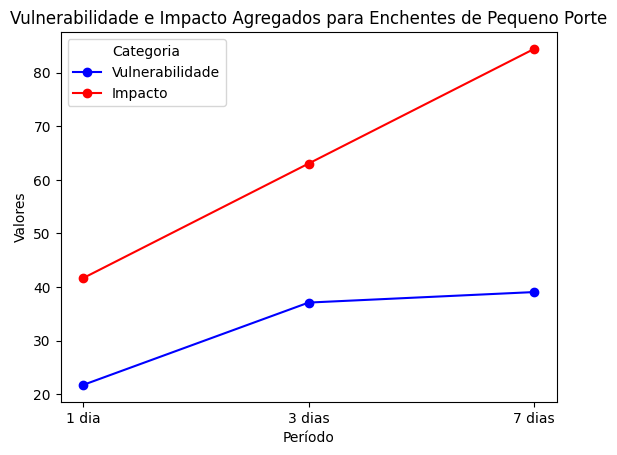

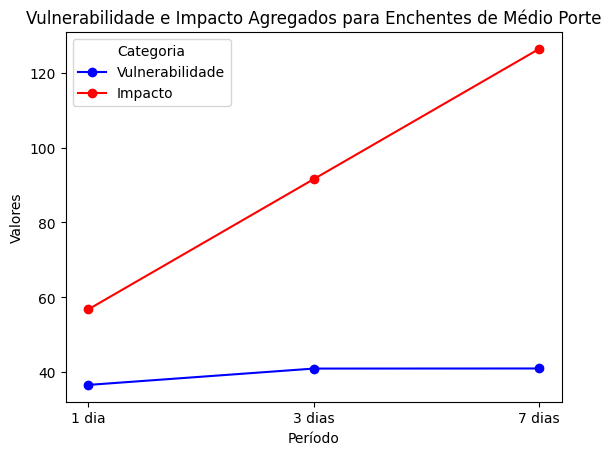

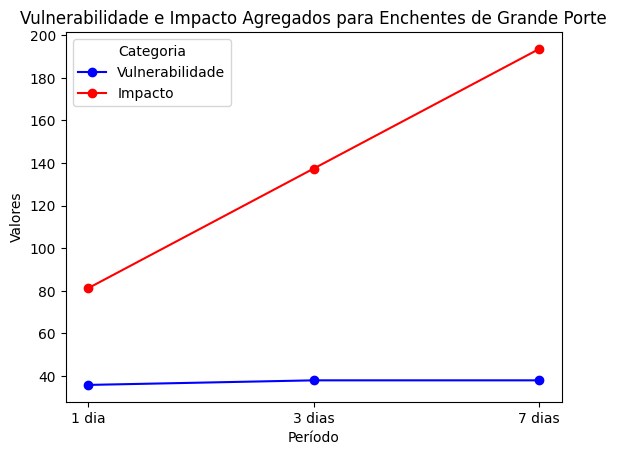

In [4]:
# Plotting with a single line for Impact and a single line for Vulnerability per flood size
for porte in portes:
    filtered_df = df[df["Porte"] == porte]
    plt.figure()
    # Aggregate Impact and Vulnerability values across days
    avg_vul = [filtered_df["1D-Vul"].mean(), filtered_df["3D-Vul"].mean(), filtered_df["7D-Vul"].mean()]
    avg_imp = [filtered_df["1D-Imp"].mean(), filtered_df["3D-Imp"].mean(), filtered_df["7D-Imp"].mean()]

    # Plot Vulnerability and Impact as single lines
    plt.plot(days_labels, avg_vul, color='blue', marker='o', label="Vulnerabilidade")
    plt.plot(days_labels, avg_imp, color='red', marker='o', label="Impacto")
    plt.xlabel("Período")
    plt.ylabel("Valores")
    plt.title(f"Vulnerabilidade e Impacto Agregados para Enchentes de {porte} Porte")
    plt.legend(title="Categoria")
    plt.show()


In [5]:
# Setting a fixed y-axis limit for consistent scaling across all three plots
y_max = max(df[["1D-Vul", "1D-Imp", "3D-Vul", "3D-Imp", "7D-Vul", "7D-Imp"]].values.max())

for porte in portes:
    filtered_df = df[df["Porte"] == porte]
    plt.figure()
    avg_vul = [filtered_df["1D-Vul"].mean(), filtered_df["3D-Vul"].mean(), filtered_df["7D-Vul"].mean()]
    avg_imp = [filtered_df["1D-Imp"].mean(), filtered_df["3D-Imp"].mean(), filtered_df["7D-Imp"].mean()]

    # Plot Vulnerability and Impact as single lines with fixed y-axis limit
    plt.plot(days_labels, avg_vul, color='blue', marker='o', label="Vulnerabilidade")
    plt.plot(days_labels, avg_imp, color='red', marker='o', label="Impacto")
    plt.xlabel("Período")
    plt.ylabel("Valores")
    plt.ylim(0, y_max)
    plt.title(f"Vulnerabilidade e Impacto Agregados para Enchentes de {porte} Porte")
    plt.legend(title="Categoria")
    plt.show()


TypeError: 'numpy.float64' object is not iterable

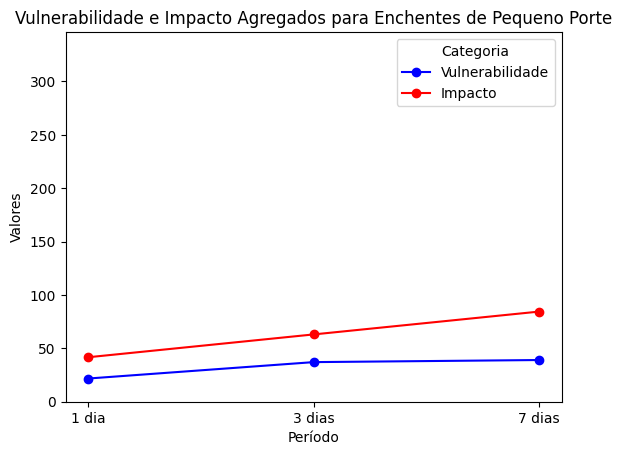

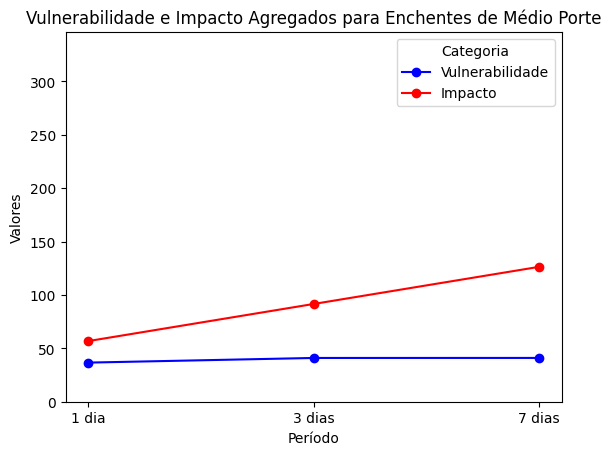

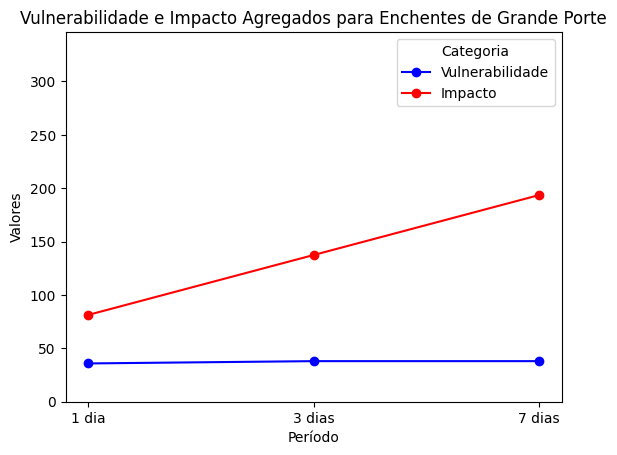

In [6]:
# Correcting the y_max calculation to ensure it retrieves the maximum value correctly
y_max = df[["1D-Vul", "1D-Imp", "3D-Vul", "3D-Imp", "7D-Vul", "7D-Imp"]].values.max()

for porte in portes:
    filtered_df = df[df["Porte"] == porte]
    plt.figure()
    avg_vul = [filtered_df["1D-Vul"].mean(), filtered_df["3D-Vul"].mean(), filtered_df["7D-Vul"].mean()]
    avg_imp = [filtered_df["1D-Imp"].mean(), filtered_df["3D-Imp"].mean(), filtered_df["7D-Imp"].mean()]

    # Plot Vulnerability and Impact as single lines with fixed y-axis limit
    plt.plot(days_labels, avg_vul, color='blue', marker='o', label="Vulnerabilidade")
    plt.plot(days_labels, avg_imp, color='red', marker='o', label="Impacto")
    plt.xlabel("Período")
    plt.ylabel("Valores")
    plt.ylim(0, y_max)
    plt.title(f"Vulnerabilidade e Impacto Agregados para Enchentes de {porte} Porte")
    plt.legend(title="Categoria")
    plt.show()


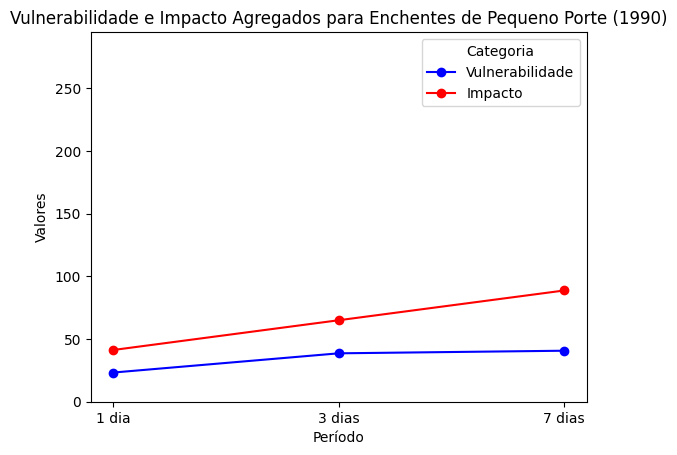

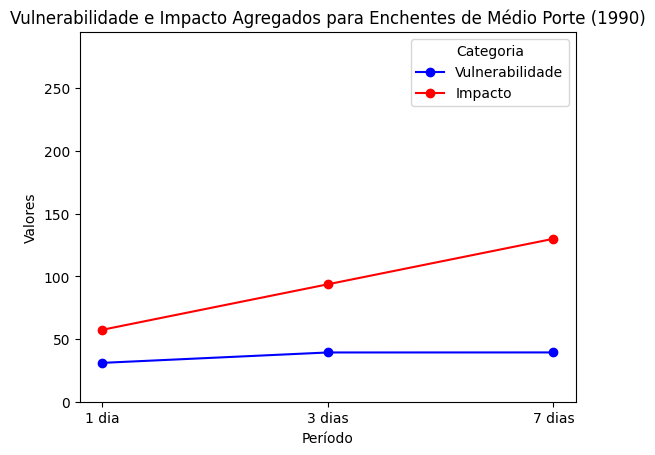

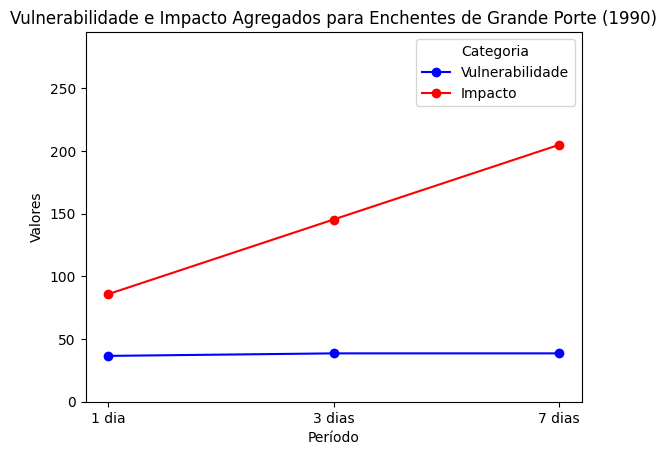

In [7]:
# Creating the DataFrame for 1990 based on the provided data from the image
data_1990 = {
    "Ano": [1990] * 9,
    "1D-Vul": [21.06, 21.67, 27.06, 29.72, 30.56, 32.66, 40.59, 33.84, 35.19],
    "1D-Imp": [22.54, 39.28, 61.92, 31.55, 59.04, 81.52, 33.77, 98.91, 124.49],
    "3D-Vul": [35.03, 39.04, 41.70, 37.47, 39.08, 41.26, 43.10, 35.38, 37.17],
    "3D-Imp": [36.58, 61.59, 96.74, 52.22, 96.99, 131.68, 55.46, 170.73, 209.58],
    "7D-Vul": [36.89, 41.52, 43.58, 37.49, 39.12, 41.29, 43.10, 35.38, 37.17],
    "7D-Imp": [50.61, 83.89, 131.55, 72.89, 134.93, 181.85, 77.15, 242.55, 294.67],
    "Porte": ["Pequeno", "Pequeno", "Pequeno", "Médio", "Médio", "Médio", "Grande", "Grande", "Grande"],
    "Intensidade": [1, 2, 3, 1, 2, 3, 1, 2, 3]
}

df_1990 = pd.DataFrame(data_1990)

# Reusing the previous plotting method with fixed y-axis limits across all three plots for the year 1990
y_max_1990 = df_1990[["1D-Vul", "1D-Imp", "3D-Vul", "3D-Imp", "7D-Vul", "7D-Imp"]].values.max()

for porte in portes:
    filtered_df = df_1990[df_1990["Porte"] == porte]
    plt.figure()
    avg_vul = [filtered_df["1D-Vul"].mean(), filtered_df["3D-Vul"].mean(), filtered_df["7D-Vul"].mean()]
    avg_imp = [filtered_df["1D-Imp"].mean(), filtered_df["3D-Imp"].mean(), filtered_df["7D-Imp"].mean()]

    # Plot Vulnerability and Impact as single lines with fixed y-axis limit
    plt.plot(days_labels, avg_vul, color='blue', marker='o', label="Vulnerabilidade")
    plt.plot(days_labels, avg_imp, color='red', marker='o', label="Impacto")
    plt.xlabel("Período")
    plt.ylabel("Valores")
    plt.ylim(0, y_max_1990)
    plt.title(f"Vulnerabilidade e Impacto Agregados para Enchentes de {porte} Porte (1990)")
    plt.legend(title="Categoria")
    plt.show()


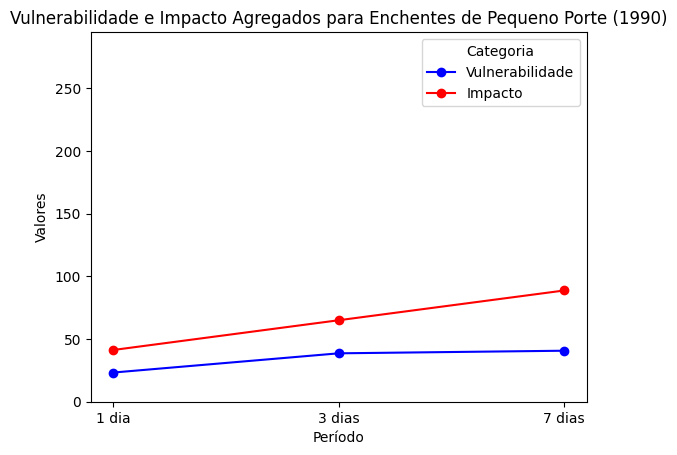

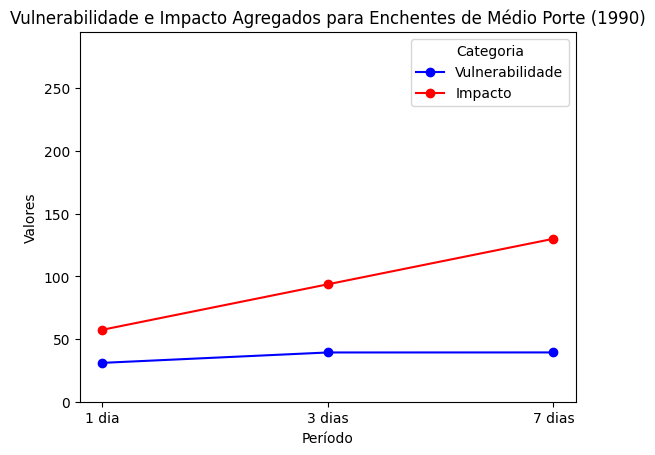

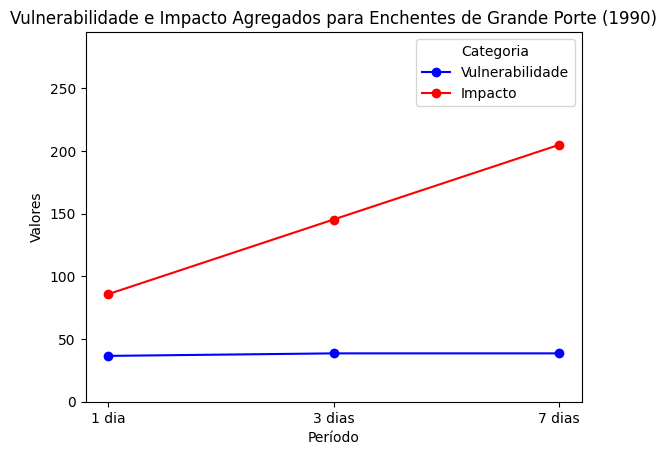

In [8]:
# Re-import necessary libraries as the environment seems to have reset
import pandas as pd
import matplotlib.pyplot as plt

# Re-create the DataFrame for 1990 based on the provided data from the image
data_1990 = {
    "Ano": [1990] * 9,
    "1D-Vul": [21.06, 21.67, 27.06, 29.72, 30.56, 32.66, 40.59, 33.84, 35.19],
    "1D-Imp": [22.54, 39.28, 61.92, 31.55, 59.04, 81.52, 33.77, 98.91, 124.49],
    "3D-Vul": [35.03, 39.04, 41.70, 37.47, 39.08, 41.26, 43.10, 35.38, 37.17],
    "3D-Imp": [36.58, 61.59, 96.74, 52.22, 96.99, 131.68, 55.46, 170.73, 209.58],
    "7D-Vul": [36.89, 41.52, 43.58, 37.49, 39.12, 41.29, 43.10, 35.38, 37.17],
    "7D-Imp": [50.61, 83.89, 131.55, 72.89, 134.93, 181.85, 77.15, 242.55, 294.67],
    "Porte": ["Pequeno", "Pequeno", "Pequeno", "Médio", "Médio", "Médio", "Grande", "Grande", "Grande"],
    "Intensidade": [1, 2, 3, 1, 2, 3, 1, 2, 3]
}

df_1990 = pd.DataFrame(data_1990)

# Set the maximum y-axis limit based on the data from 1990 for consistent scaling across all plots
y_max_1990 = df_1990[["1D-Vul", "1D-Imp", "3D-Vul", "3D-Imp", "7D-Vul", "7D-Imp"]].values.max()
days_labels = ["1 dia", "3 dias", "7 dias"]
portes = ["Pequeno", "Médio", "Grande"]

# Plotting graphs for each flood size (Porte) with consistent y-axis limits
for porte in portes:
    filtered_df = df_1990[df_1990["Porte"] == porte]
    plt.figure()
    avg_vul = [filtered_df["1D-Vul"].mean(), filtered_df["3D-Vul"].mean(), filtered_df["7D-Vul"].mean()]
    avg_imp = [filtered_df["1D-Imp"].mean(), filtered_df["3D-Imp"].mean(), filtered_df["7D-Imp"].mean()]

    # Plot Vulnerability and Impact as single lines with fixed y-axis limit
    plt.plot(days_labels, avg_vul, color='blue', marker='o', label="Vulnerabilidade")
    plt.plot(days_labels, avg_imp, color='red', marker='o', label="Impacto")
    plt.xlabel("Período")
    plt.ylabel("Valores")
    plt.ylim(0, y_max_1990)
    plt.title(f"Vulnerabilidade e Impacto Agregados para Enchentes de {porte} Porte (1990)")
    plt.legend(title="Categoria")
    plt.show()


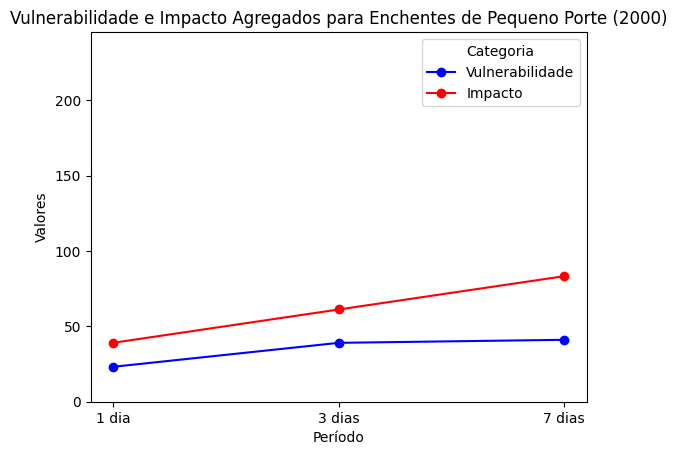

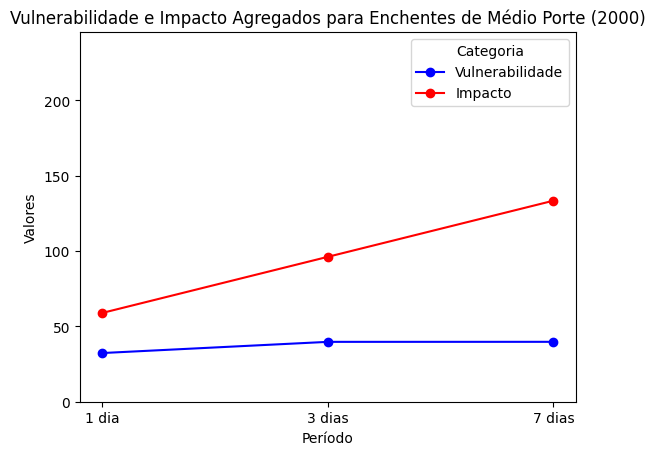

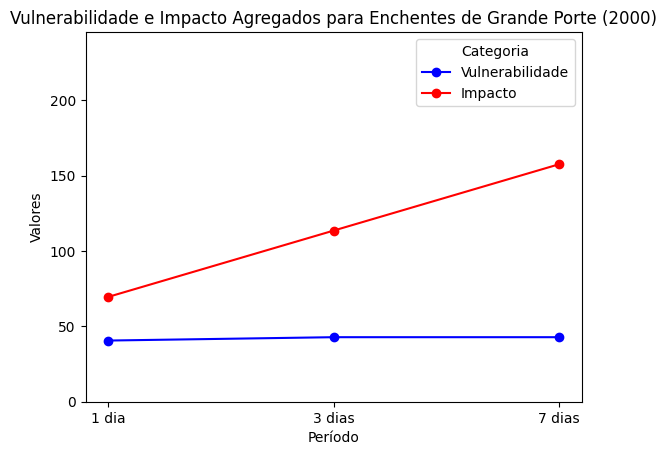

In [9]:
# Creating the DataFrame for 2000 based on the provided data from the image
data_2000 = {
    "Ano": [2000] * 9,
    "1D-Vul": [22.48, 23.68, 23.39, 32.48, 27.08, 37.37, 41.18, 42.07, 38.53],
    "1D-Imp": [24.60, 37.48, 55.26, 28.99, 66.77, 81.07, 34.54, 66.48, 107.56],
    "3D-Vul": [33.45, 41.85, 41.94, 40.29, 33.66, 45.24, 43.34, 44.60, 40.53],
    "3D-Imp": [40.41, 58.10, 85.12, 47.05, 112.61, 128.83, 56.44, 107.78, 176.41],
    "7D-Vul": [34.96, 44.18, 44.14, 40.32, 33.68, 45.25, 43.34, 44.60, 40.53],
    "7D-Imp": [56.23, 78.73, 114.97, 65.11, 158.45, 176.60, 78.33, 149.07, 245.27],
    "Porte": ["Pequeno", "Pequeno", "Pequeno", "Médio", "Médio", "Médio", "Grande", "Grande", "Grande"],
    "Intensidade": [1, 2, 3, 1, 2, 3, 1, 2, 3]
}

df_2000 = pd.DataFrame(data_2000)

# Setting a maximum y-axis limit for consistent scaling across all three plots for the year 2000
y_max_2000 = df_2000[["1D-Vul", "1D-Imp", "3D-Vul", "3D-Imp", "7D-Vul", "7D-Imp"]].values.max()

# Plotting graphs for each flood size (Porte) with consistent y-axis limits
for porte in portes:
    filtered_df = df_2000[df_2000["Porte"] == porte]
    plt.figure()
    avg_vul = [filtered_df["1D-Vul"].mean(), filtered_df["3D-Vul"].mean(), filtered_df["7D-Vul"].mean()]
    avg_imp = [filtered_df["1D-Imp"].mean(), filtered_df["3D-Imp"].mean(), filtered_df["7D-Imp"].mean()]

    # Plot Vulnerability and Impact as single lines with fixed y-axis limit
    plt.plot(days_labels, avg_vul, color='blue', marker='o', label="Vulnerabilidade")
    plt.plot(days_labels, avg_imp, color='red', marker='o', label="Impacto")
    plt.xlabel("Período")
    plt.ylabel("Valores")
    plt.ylim(0, y_max_2000)
    plt.title(f"Vulnerabilidade e Impacto Agregados para Enchentes de {porte} Porte (2000)")
    plt.legend(title="Categoria")
    plt.show()


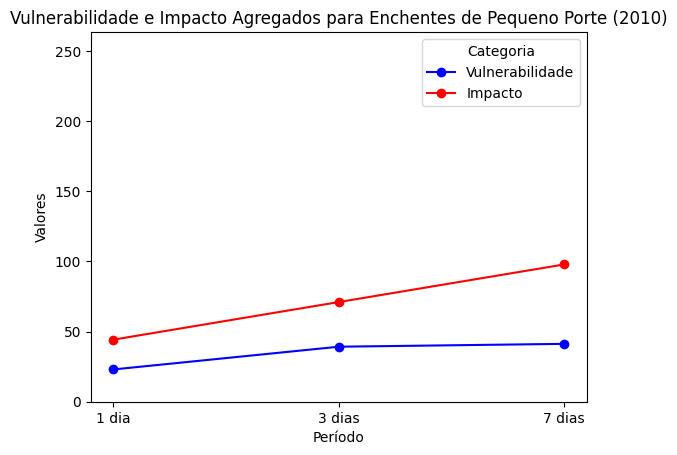

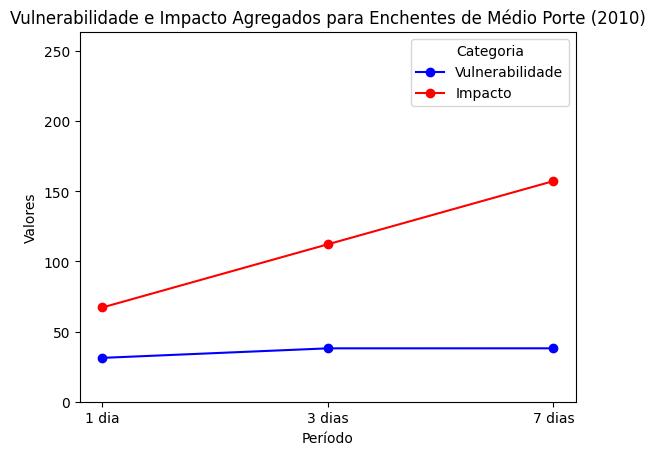

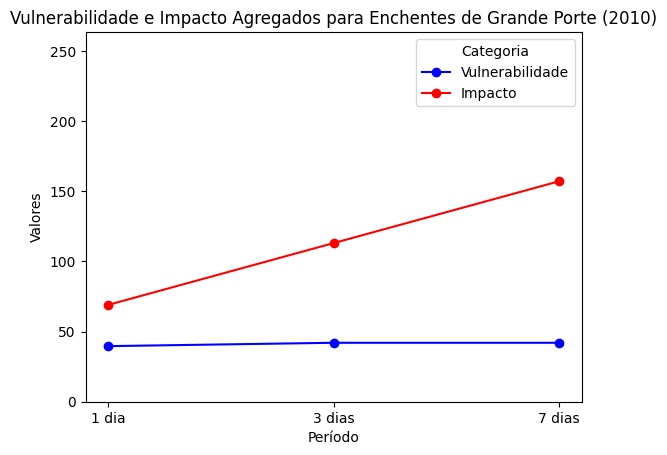

In [10]:
# Creating the DataFrame for 2010 based on the provided data from the image
data_2010 = {
    "Ano": [2010] * 9,
    "1D-Vul": [20.72, 27.63, 20.69, 31.93, 33.16, 28.72, 38.66, 42.00, 38.23],
    "1D-Imp": [19.07, 39.70, 73.96, 27.70, 64.09, 109.87, 34.79, 67.53, 104.76],
    "3D-Vul": [39.80, 43.93, 33.95, 39.78, 39.88, 34.53, 41.33, 44.20, 40.56],
    "3D-Imp": [29.88, 61.43, 121.88, 44.88, 105.21, 186.69, 57.50, 109.65, 172.14],
    "7D-Vul": [42.21, 45.79, 35.77, 39.79, 39.91, 34.55, 41.33, 44.20, 40.56],
    "7D-Imp": [40.68, 83.16, 169.81, 62.06, 146.34, 263.52, 80.20, 151.77, 239.51],
    "Porte": ["Pequeno", "Pequeno", "Pequeno", "Médio", "Médio", "Médio", "Grande", "Grande", "Grande"],
    "Intensidade": [1, 2, 3, 1, 2, 3, 1, 2, 3]
}

df_2010 = pd.DataFrame(data_2010)

# Setting a maximum y-axis limit for consistent scaling across all three plots for the year 2010
y_max_2010 = df_2010[["1D-Vul", "1D-Imp", "3D-Vul", "3D-Imp", "7D-Vul", "7D-Imp"]].values.max()

# Plotting graphs for each flood size (Porte) with consistent y-axis limits
for porte in portes:
    filtered_df = df_2010[df_2010["Porte"] == porte]
    plt.figure()
    avg_vul = [filtered_df["1D-Vul"].mean(), filtered_df["3D-Vul"].mean(), filtered_df["7D-Vul"].mean()]
    avg_imp = [filtered_df["1D-Imp"].mean(), filtered_df["3D-Imp"].mean(), filtered_df["7D-Imp"].mean()]

    # Plot Vulnerability and Impact as single lines with fixed y-axis limit
    plt.plot(days_labels, avg_vul, color='blue', marker='o', label="Vulnerabilidade")
    plt.plot(days_labels, avg_imp, color='red', marker='o', label="Impacto")
    plt.xlabel("Período")
    plt.ylabel("Valores")
    plt.ylim(0, y_max_2010)
    plt.title(f"Vulnerabilidade e Impacto Agregados para Enchentes de {porte} Porte (2010)")
    plt.legend(title="Categoria")
    plt.show()


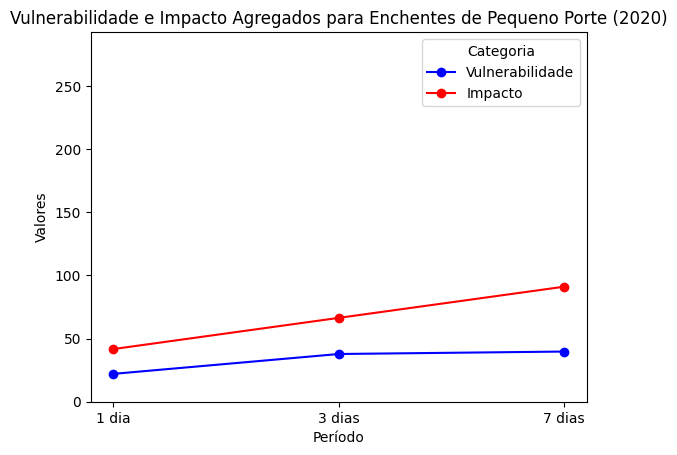

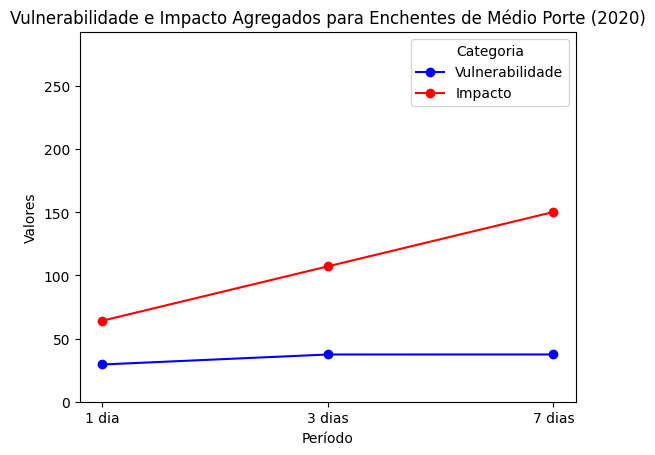

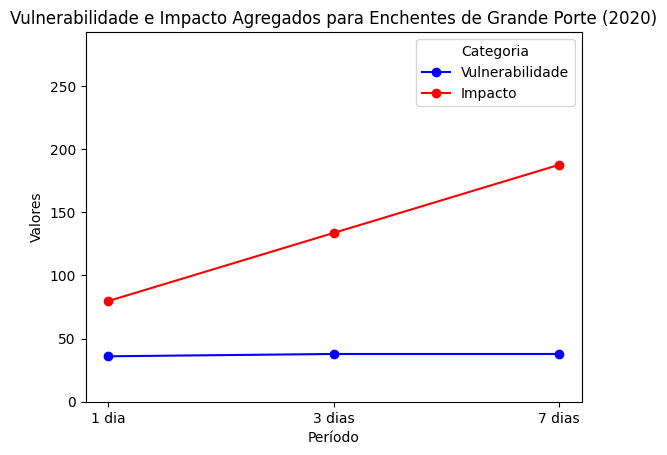

In [11]:
# Creating the DataFrame for 2020 based on the provided data from the image
data_2020 = {
    "Ano": [2020] * 9,
    "1D-Vul": [24.59, 21.72, 19.86, 33.29, 27.22, 27.95, 33.33, 38.74, 35.86],
    "1D-Imp": [20.77, 44.21, 60.13, 26.31, 61.83, 104.39, 42.32, 73.27, 123.46],
    "3D-Vul": [40.47, 34.62, 38.28, 42.43, 35.45, 34.32, 35.09, 40.56, 37.78],
    "3D-Imp": [32.62, 71.22, 95.37, 42.33, 102.90, 176.40, 72.06, 120.78, 208.07],
    "7D-Vul": [42.21, 36.36, 40.62, 42.44, 35.47, 34.34, 35.09, 40.56, 37.78],
    "7D-Imp": [44.47, 98.24, 130.61, 58.35, 143.96, 248.41, 101.81, 168.28, 292.68],
    "Porte": ["Pequeno", "Pequeno", "Pequeno", "Médio", "Médio", "Médio", "Grande", "Grande", "Grande"],
    "Intensidade": [1, 2, 3, 1, 2, 3, 1, 2, 3]
}

df_2020 = pd.DataFrame(data_2020)

# Setting a maximum y-axis limit for consistent scaling across all three plots for the year 2020
y_max_2020 = df_2020[["1D-Vul", "1D-Imp", "3D-Vul", "3D-Imp", "7D-Vul", "7D-Imp"]].values.max()

# Plotting graphs for each flood size (Porte) with consistent y-axis limits
for porte in portes:
    filtered_df = df_2020[df_2020["Porte"] == porte]
    plt.figure()
    avg_vul = [filtered_df["1D-Vul"].mean(), filtered_df["3D-Vul"].mean(), filtered_df["7D-Vul"].mean()]
    avg_imp = [filtered_df["1D-Imp"].mean(), filtered_df["3D-Imp"].mean(), filtered_df["7D-Imp"].mean()]

    # Plot Vulnerability and Impact as single lines with fixed y-axis limit
    plt.plot(days_labels, avg_vul, color='blue', marker='o', label="Vulnerabilidade")
    plt.plot(days_labels, avg_imp, color='red', marker='o', label="Impacto")
    plt.xlabel("Período")
    plt.ylabel("Valores")
    plt.ylim(0, y_max_2020)
    plt.title(f"Vulnerabilidade e Impacto Agregados para Enchentes de {porte} Porte (2020)")
    plt.legend(title="Categoria")
    plt.show()


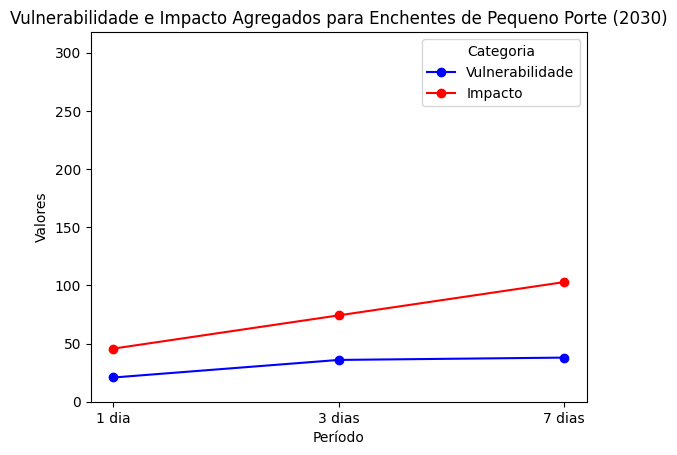

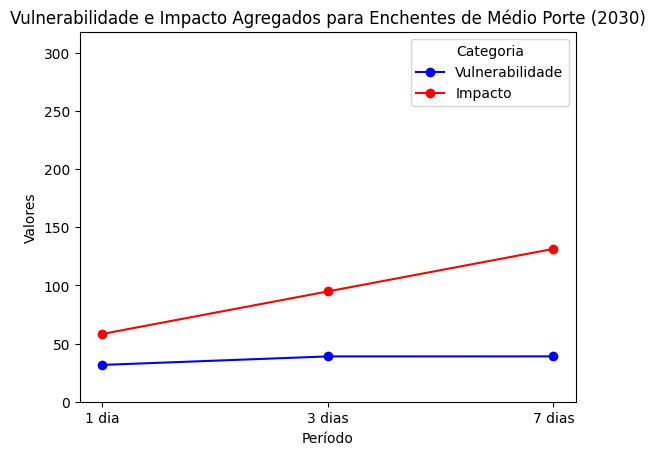

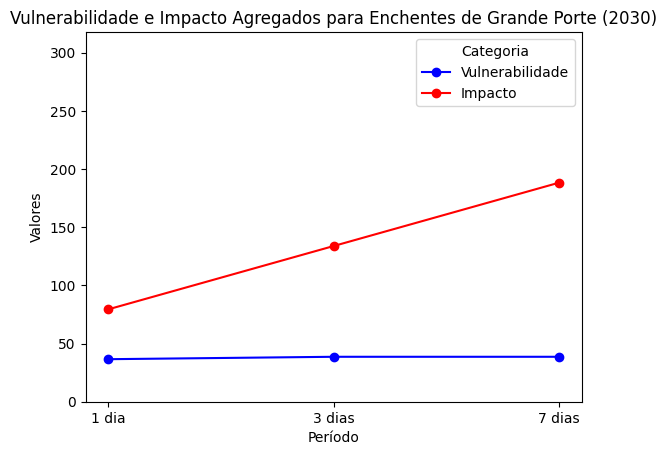

In [12]:
# Creating the DataFrame for 2030 based on the provided data from the image
data_2030 = {
    "Ano": [2030] * 9,
    "1D-Vul": [21.84, 19.81, 20.81, 28.97, 34.55, 31.41, 39.58, 37.81, 32.26],
    "1D-Imp": [19.34, 58.23, 59.36, 33.05, 55.03, 86.76, 34.70, 72.67, 130.72],
    "3D-Vul": [38.73, 30.20, 38.84, 36.15, 42.39, 38.29, 41.92, 39.89, 34.07],
    "3D-Imp": [30.32, 98.89, 93.50, 55.17, 88.53, 140.75, 56.75, 120.49, 224.19],
    "7D-Vul": [41.05, 31.56, 41.16, 36.17, 42.41, 38.33, 41.92, 39.89, 34.07],
    "7D-Imp": [41.30, 139.54, 127.64, 77.29, 122.03, 194.73, 78.80, 168.32, 317.67],
    "Porte": ["Pequeno", "Pequeno", "Pequeno", "Médio", "Médio", "Médio", "Grande", "Grande", "Grande"],
    "Intensidade": [1, 2, 3, 1, 2, 3, 1, 2, 3]
}

df_2030 = pd.DataFrame(data_2030)

# Setting a maximum y-axis limit for consistent scaling across all three plots for the year 2030
y_max_2030 = df_2030[["1D-Vul", "1D-Imp", "3D-Vul", "3D-Imp", "7D-Vul", "7D-Imp"]].values.max()

# Plotting graphs for each flood size (Porte) with consistent y-axis limits
for porte in portes:
    filtered_df = df_2030[df_2030["Porte"] == porte]
    plt.figure()
    avg_vul = [filtered_df["1D-Vul"].mean(), filtered_df["3D-Vul"].mean(), filtered_df["7D-Vul"].mean()]
    avg_imp = [filtered_df["1D-Imp"].mean(), filtered_df["3D-Imp"].mean(), filtered_df["7D-Imp"].mean()]

    # Plot Vulnerability and Impact as single lines with fixed y-axis limit
    plt.plot(days_labels, avg_vul, color='blue', marker='o', label="Vulnerabilidade")
    plt.plot(days_labels, avg_imp, color='red', marker='o', label="Impacto")
    plt.xlabel("Período")
    plt.ylabel("Valores")
    plt.ylim(0, y_max_2030)
    plt.title(f"Vulnerabilidade e Impacto Agregados para Enchentes de {porte} Porte (2030)")
    plt.legend(title="Categoria")
    plt.show()


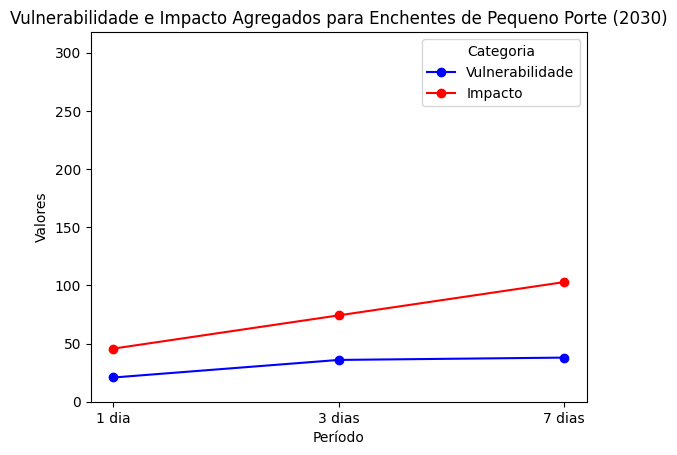

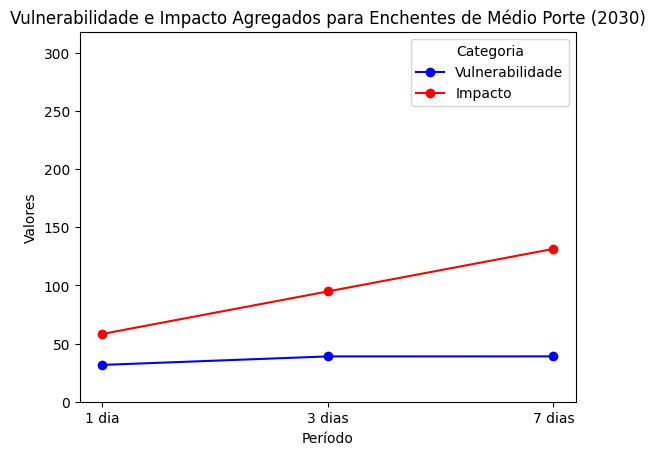

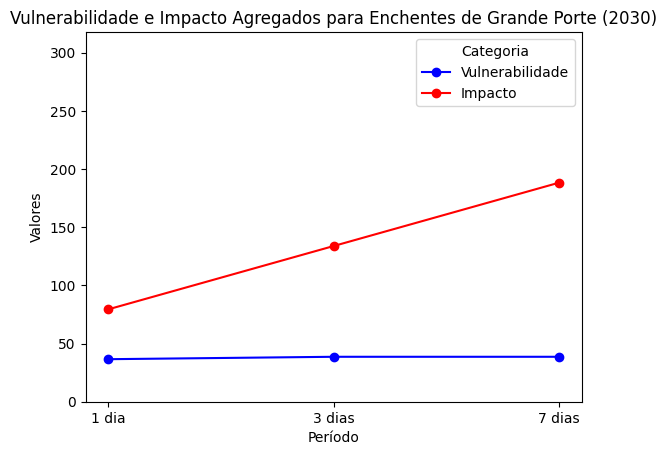

In [13]:
# Re-import necessary libraries as the environment seems to have reset
import pandas as pd
import matplotlib.pyplot as plt

# Re-create the DataFrame for 2030 based on the provided data from the image
data_2030 = {
    "Ano": [2030] * 9,
    "1D-Vul": [21.84, 19.81, 20.81, 28.97, 34.55, 31.41, 39.58, 37.81, 32.26],
    "1D-Imp": [19.34, 58.23, 59.36, 33.05, 55.03, 86.76, 34.70, 72.67, 130.72],
    "3D-Vul": [38.73, 30.20, 38.84, 36.15, 42.39, 38.29, 41.92, 39.89, 34.07],
    "3D-Imp": [30.32, 98.89, 93.50, 55.17, 88.53, 140.75, 56.75, 120.49, 224.19],
    "7D-Vul": [41.05, 31.56, 41.16, 36.17, 42.41, 38.33, 41.92, 39.89, 34.07],
    "7D-Imp": [41.30, 139.54, 127.64, 77.29, 122.03, 194.73, 78.80, 168.32, 317.67],
    "Porte": ["Pequeno", "Pequeno", "Pequeno", "Médio", "Médio", "Médio", "Grande", "Grande", "Grande"],
    "Intensidade": [1, 2, 3, 1, 2, 3, 1, 2, 3]
}

df_2030 = pd.DataFrame(data_2030)

# Set a maximum y-axis limit for consistent scaling across all three plots for the year 2030
y_max_2030 = df_2030[["1D-Vul", "1D-Imp", "3D-Vul", "3D-Imp", "7D-Vul", "7D-Imp"]].values.max()
days_labels = ["1 dia", "3 dias", "7 dias"]
portes = ["Pequeno", "Médio", "Grande"]

# Plotting graphs for each flood size (Porte) with consistent y-axis limits
for porte in portes:
    filtered_df = df_2030[df_2030["Porte"] == porte]
    plt.figure()
    avg_vul = [filtered_df["1D-Vul"].mean(), filtered_df["3D-Vul"].mean(), filtered_df["7D-Vul"].mean()]
    avg_imp = [filtered_df["1D-Imp"].mean(), filtered_df["3D-Imp"].mean(), filtered_df["7D-Imp"].mean()]

    # Plot Vulnerability and Impact as single lines with fixed y-axis limit
    plt.plot(days_labels, avg_vul, color='blue', marker='o', label="Vulnerabilidade")
    plt.plot(days_labels, avg_imp, color='red', marker='o', label="Impacto")
    plt.xlabel("Período")
    plt.ylabel("Valores")
    plt.ylim(0, y_max_2030)
    plt.title(f"Vulnerabilidade e Impacto Agregados para Enchentes de {porte} Porte (2030)")
    plt.legend(title="Categoria")
    plt.show()
